# **1. Perkenalan Dataset**

Notebook eksperimen ini menggunakan **Wine Recognition Dataset** yang tersedia
melalui scikit-learn dan berasal dari UCI Machine Learning Repository. Dataset
berisi 178 sampel wine, 13 fitur numerik hasil analisis kimia, dan 3 kelas
target. Tujuan eksperimen adalah menyiapkan data klasifikasi multikelas yang
bersih dan siap dilatih.

Tahapan eksperimen dilakukan manual mengikuti
struktur template: import library, data loading, EDA, dan preprocessing.
Dataset mentah disimpan pada `../wine_raw.csv`, sedangkan hasil preprocessing
disimpan sebagai `wine_preprocessing.csv`.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Library berhasil dimuat.")

Library berhasil dimuat.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
RAW_DATA_PATH = Path("../wine_raw.csv")

df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Ukuran dataset: {df_raw.shape}")
display(df_raw.head())

print("\nTipe data:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nDistribusi kelas:")
display(df_raw["target"].value_counts().sort_index().to_frame("jumlah"))

Ukuran dataset: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Tipe data:


,dtype
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64



Distribusi kelas:


,jumlah
target,
0,59
1,71
2,48


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


,missing_value,unique_value
alcohol,0,126
malic_acid,0,133
ash,0,79
alcalinity_of_ash,0,63
magnesium,0,53
total_phenols,0,97
flavanoids,0,132
nonflavanoid_phenols,0,39
proanthocyanins,0,101
color_intensity,0,132


Jumlah baris duplikat: 0


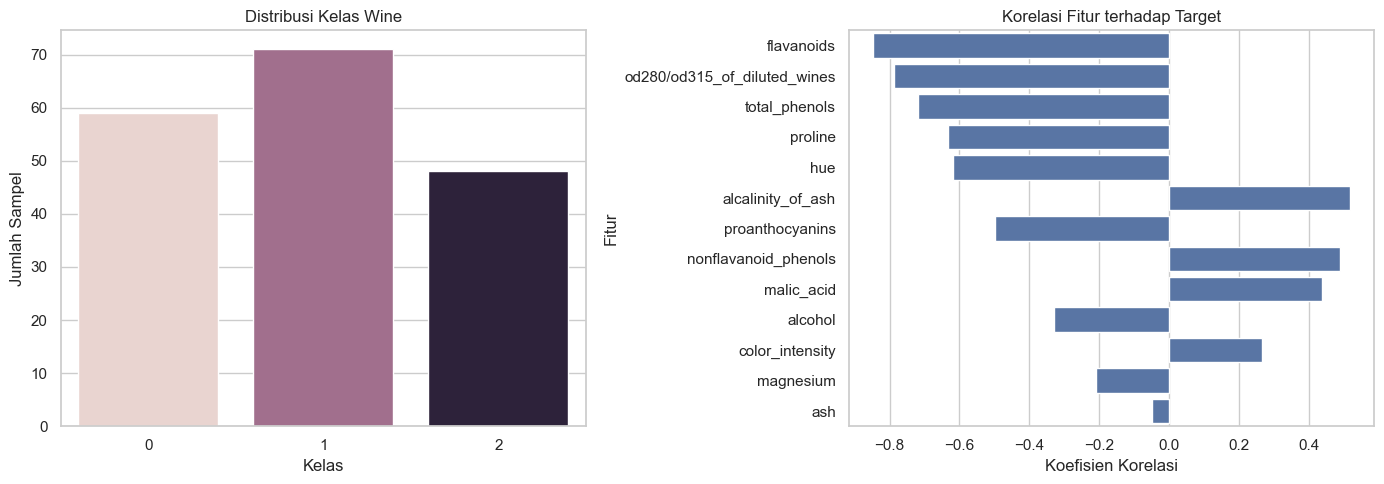

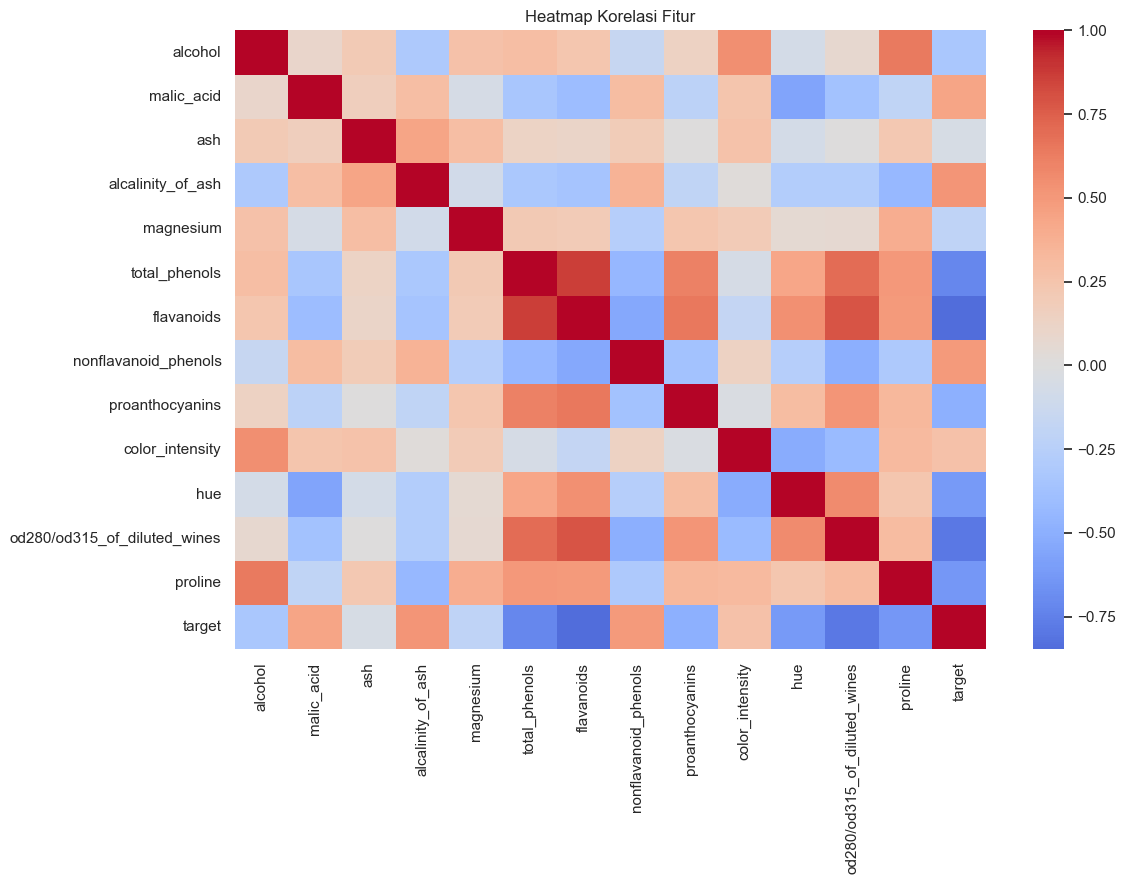

In [3]:
# Statistik deskriptif
display(df_raw.describe().T)

# Pemeriksaan kualitas data
quality_summary = pd.DataFrame({
    "missing_value": df_raw.isna().sum(),
    "unique_value": df_raw.nunique(),
})
display(quality_summary)
print(f"Jumlah baris duplikat: {df_raw.duplicated().sum()}")

# Distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_raw, x="target", hue="target", legend=False, ax=axes[0])
axes[0].set_title("Distribusi Kelas Wine")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")

# Korelasi fitur dengan target
correlations = (
    df_raw.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)
sns.barplot(x=correlations.values, y=correlations.index, ax=axes[1])
axes[1].set_title("Korelasi Fitur terhadap Target")
axes[1].set_xlabel("Koefisien Korelasi")
axes[1].set_ylabel("Fitur")
plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(12, 9))
sns.heatmap(df_raw.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Fitur")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
def preprocess_wine_data(dataframe):
    processed = dataframe.copy()
    processed = processed.drop_duplicates().reset_index(drop=True)

    feature_columns = [column for column in processed.columns if column != "target"]
    for column in feature_columns:
        processed[column] = pd.to_numeric(processed[column], errors="coerce")
        processed[column] = processed[column].fillna(processed[column].median())

        lower_limit = processed[column].quantile(0.01)
        upper_limit = processed[column].quantile(0.99)
        processed[column] = processed[column].clip(lower_limit, upper_limit)

    processed["target"] = pd.to_numeric(
        processed["target"], errors="raise"
    ).astype(int)
    return processed


df_processed = preprocess_wine_data(df_raw)
OUTPUT_PATH = Path("wine_preprocessing.csv")
df_processed.to_csv(OUTPUT_PATH, index=False)

print(f"Data hasil preprocessing: {df_processed.shape}")
print(f"Missing value tersisa: {df_processed.isna().sum().sum()}")
print(f"Duplikat tersisa: {df_processed.duplicated().sum()}")
print(f"File tersimpan di: {OUTPUT_PATH.resolve()}")
display(df_processed.head())

Data hasil preprocessing: (178, 14)
Missing value tersisa: 0
Duplikat tersisa: 0
File tersimpan di: /Users/mac/Documents/help me finish advaced quiz/quiz4-msml/Eksperimen_SML_adiab/preprocessing/wine_preprocessing.csv


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.600,127.0,2.8000,3.06,0.28,2.29,5.64,1.04,3.843,1065.0,0
1,13.20,1.78,2.14,11.354,100.0,2.6500,2.76,0.26,1.28,4.38,1.05,3.400,1050.0,0
2,13.16,2.36,2.67,18.600,101.0,2.8000,3.24,0.30,2.81,5.68,1.03,3.170,1185.0,0
3,14.37,1.95,2.50,16.800,113.0,3.5959,3.49,0.24,2.18,7.80,0.86,3.450,1480.0,0
4,13.24,2.59,2.87,21.000,118.0,2.8000,2.69,0.39,1.82,4.32,1.04,2.930,735.0,0


## **6. Kesimpulan**

Dataset telah dimuat, dianalisis, dibersihkan dari duplikasi, diimputasi bila
terdapat nilai kosong, dan dibatasi pada persentil 1-99 untuk mengurangi dampak
outlier ekstrem. Hasil akhir siap digunakan untuk pelatihan model.

In [5]:
assert df_processed.shape[1] == 14
assert df_processed.isna().sum().sum() == 0
assert set(df_processed["target"].unique()) == {0, 1, 2}
print("VALIDASI BERHASIL: dataset siap dilatih.")

VALIDASI BERHASIL: dataset siap dilatih.
